In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

cwd = Path.cwd()
print("Current working directory:", cwd)

if (cwd / "outputs" / "metrics").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "outputs" / "metrics").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Could not find outputs/metrics. Check notebook working directory.")

print("Project root:", PROJECT_ROOT)

ROOT = PROJECT_ROOT / "outputs"
METRICS = ROOT / "metrics"
PLOTS = ROOT / "plots" / "final"
PLOTS.mkdir(parents=True, exist_ok=True)

models = {
    "LLaVA-1.5-7B": METRICS / "llava7b",
    "LLaVA-1.5-13B": METRICS / "llava13b",
}

for model_name, folder in models.items():
    print(model_name, folder.exists(), folder)
    if folder.exists():
        print([p.name for p in folder.glob("*.csv")])

Current working directory: c:\Users\payal\region-vlm-uncertainty\notebooks
Project root: c:\Users\payal\region-vlm-uncertainty
LLaVA-1.5-7B True c:\Users\payal\region-vlm-uncertainty\outputs\metrics\llava7b
['low_uncertainty_control_answer_flips.csv', 'low_uncertainty_control_paired_bootstrap.csv', 'low_uncertainty_control_sample_level.csv', 'low_uncertainty_control_summary.csv', 'original_sanity_answer_flips.csv', 'original_sanity_paired_bootstrap.csv', 'original_sanity_sample_level.csv', 'original_sanity_summary.csv', 'random_control_answer_flips.csv', 'random_control_multiseed_per_seed.csv', 'random_control_multiseed_pooled_bootstrap.csv', 'random_control_multiseed_sample_level.csv', 'random_control_multiseed_summary.csv', 'random_control_paired_comparison.csv', 'random_control_sample_level.csv', 'random_control_summary.csv', 'removed_eval_active_suppression_ablation.csv', 'removed_eval_all_captions_long.csv', 'removed_eval_answer_flips.csv', 'removed_eval_bootstrap_effects.csv', 'r

In [2]:
def load_model_results(model_name, folder):
    summary_path = folder / "removed_eval_summary.csv"
    bootstrap_path = folder / "removed_eval_bootstrap_effects.csv"
    flips_path = folder / "removed_eval_answer_flips.csv"
    region_path = folder / "removed_eval_region_summary.csv"

    for p in [summary_path, bootstrap_path, flips_path, region_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing file: {p}")

    summary = pd.read_csv(summary_path)
    bootstrap = pd.read_csv(bootstrap_path)
    flips = pd.read_csv(flips_path)
    region = pd.read_csv(region_path)

    summary["model"] = model_name
    bootstrap["model"] = model_name
    flips["model"] = model_name
    region["model"] = model_name

    return summary, bootstrap, flips, region


summaries = []
bootstraps = []
flips = []
regions = []

for model_name, folder in models.items():
    s, b, f, r = load_model_results(model_name, folder)
    summaries.append(s)
    bootstraps.append(b)
    flips.append(f)
    regions.append(r)

summary_df = pd.concat(summaries, ignore_index=True)
bootstrap_df = pd.concat(bootstraps, ignore_index=True)
flips_df = pd.concat(flips, ignore_index=True)
region_df = pd.concat(regions, ignore_index=True)

summary_df

,condition,n,hallucinated_yes,correct_rejection_no,unclear_other,hallucination_rate,correct_rejection_rate,unclear_rate,causal_effect_vs_none,model
0,none,522,415,107,0,0.795019,0.204981,0.0,0.000000,LLaVA-1.5-7B
1,all,522,396,126,0,0.758621,0.241379,0.0,0.036398,LLaVA-1.5-7B
2,removed,522,409,113,0,0.783525,0.216475,0.0,0.011494,LLaVA-1.5-7B
3,context,522,412,110,0,0.789272,0.210728,0.0,0.005747,LLaVA-1.5-7B
4,background,522,399,123,0,0.764368,0.235632,0.0,0.030651,LLaVA-1.5-7B
5,none,522,463,59,0,0.886973,0.113027,0.0,0.000000,LLaVA-1.5-13B
6,all,522,466,56,0,0.892720,0.107280,0.0,-0.005747,LLaVA-1.5-13B
7,removed,522,466,56,0,0.892720,0.107280,0.0,-0.005747,LLaVA-1.5-13B
8,context,522,464,58,0,0.888889,0.111111,0.0,-0.001916,LLaVA-1.5-13B
9,background,522,466,56,0,0.892720,0.107280,0.0,-0.005747,LLaVA-1.5-13B


In [3]:
table = summary_df.copy()
table["hallucination_rate_percent"] = table["hallucination_rate"] * 100
table["causal_effect_pp"] = table["causal_effect_vs_none"] * 100

table[
    [
        "model",
        "condition",
        "n",
        "hallucinated_yes",
        "correct_rejection_no",
        "hallucination_rate_percent",
        "causal_effect_pp",
    ]
].round(3)

,model,condition,n,hallucinated_yes,correct_rejection_no,hallucination_rate_percent,causal_effect_pp
0,LLaVA-1.5-7B,none,522,415,107,79.502,0.000
1,LLaVA-1.5-7B,all,522,396,126,75.862,3.640
2,LLaVA-1.5-7B,removed,522,409,113,78.352,1.149
3,LLaVA-1.5-7B,context,522,412,110,78.927,0.575
4,LLaVA-1.5-7B,background,522,399,123,76.437,3.065
5,LLaVA-1.5-13B,none,522,463,59,88.697,0.000
6,LLaVA-1.5-13B,all,522,466,56,89.272,-0.575
7,LLaVA-1.5-13B,removed,522,466,56,89.272,-0.575
8,LLaVA-1.5-13B,context,522,464,58,88.889,-0.192
9,LLaVA-1.5-13B,background,522,466,56,89.272,-0.575


In [4]:
boot_table = bootstrap_df.copy()

boot_table[
    [
        "model",
        "condition",
        "observed_effect_percentage_points",
        "ci_low_percentage_points",
        "ci_high_percentage_points",
        "p_value_approx",
    ]
].round(4)

,model,condition,observed_effect_percentage_points,ci_low_percentage_points,ci_high_percentage_points,p_value_approx
0,LLaVA-1.5-7B,all,3.6398,1.5326,5.9387,0.0014
1,LLaVA-1.5-7B,removed,1.1494,0.0000,2.2989,0.0642
2,LLaVA-1.5-7B,context,0.5747,-0.5747,1.7241,0.3840
3,LLaVA-1.5-7B,background,3.0651,0.9579,5.1724,0.0036
4,LLaVA-1.5-13B,all,-0.5747,-2.6820,1.7241,0.6702
5,LLaVA-1.5-13B,removed,-0.5747,-1.7241,0.5747,0.3932
6,LLaVA-1.5-13B,context,-0.1916,-0.9579,0.5747,0.8428
7,LLaVA-1.5-13B,background,-0.5747,-2.6820,1.5326,0.6556


In [5]:
flips_df

,condition,total,yes_to_no,no_to_yes,unchanged_yes,unchanged_no,unknown_changes,net_hallucination_reduction,model
0,all,522,28,9,387,98,0,19,LLaVA-1.5-7B
1,removed,522,8,2,407,105,0,6,LLaVA-1.5-7B
2,context,522,6,3,409,104,0,3,LLaVA-1.5-7B
3,background,522,23,7,392,100,0,16,LLaVA-1.5-7B
4,all,522,16,19,447,40,0,-3,LLaVA-1.5-13B
5,removed,522,3,6,460,53,0,-3,LLaVA-1.5-13B
6,context,522,2,3,461,56,0,-1,LLaVA-1.5-13B
7,background,522,15,18,448,41,0,-3,LLaVA-1.5-13B


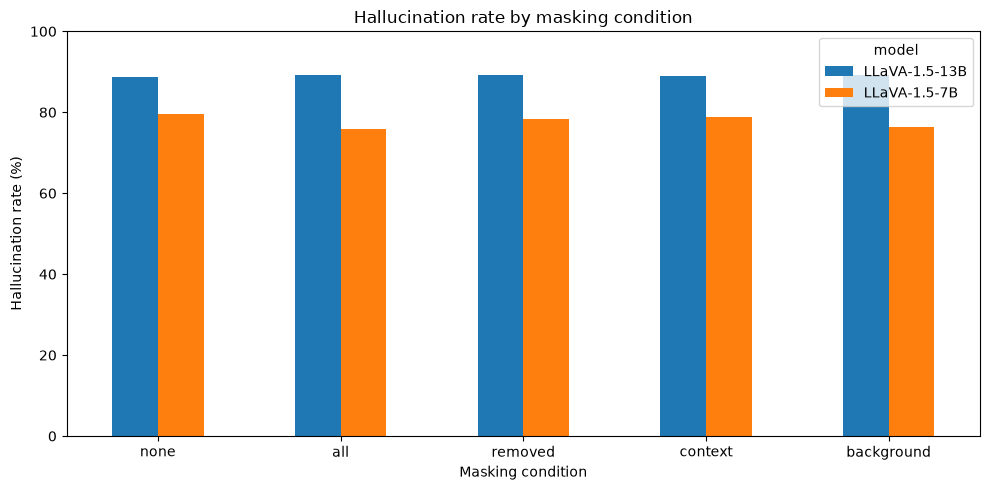

WindowsPath('c:/Users/payal/region-vlm-uncertainty/outputs/plots/final/comparison_hallucination_rate.png')

In [6]:
plot_df = summary_df.copy()
plot_df["hallucination_rate_percent"] = plot_df["hallucination_rate"] * 100

pivot = plot_df.pivot(index="condition", columns="model", values="hallucination_rate_percent")
pivot = pivot.loc[["none", "all", "removed", "context", "background"]]

ax = pivot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Hallucination rate by masking condition")
ax.set_xlabel("Masking condition")
ax.set_ylabel("Hallucination rate (%)")
ax.set_ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()

out = PLOTS / "comparison_hallucination_rate.png"
plt.savefig(out, dpi=200)
plt.show()

out

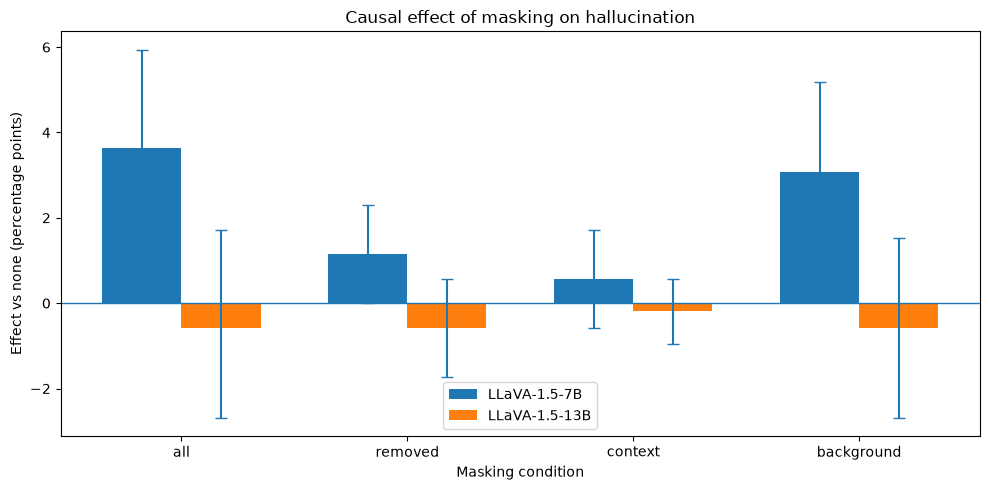

WindowsPath('c:/Users/payal/region-vlm-uncertainty/outputs/plots/final/comparison_causal_effect_with_ci.png')

In [7]:
effect_df = bootstrap_df.copy()
effect_df = effect_df[effect_df["condition"].isin(["all", "removed", "context", "background"])]

conditions = ["all", "removed", "context", "background"]

fig, ax = plt.subplots(figsize=(10, 5))

x_positions = range(len(conditions))
width = 0.35

for i, model in enumerate(["LLaVA-1.5-7B", "LLaVA-1.5-13B"]):
    sub = effect_df[effect_df["model"] == model].set_index("condition").loc[conditions]

    x = [p + (i - 0.5) * width for p in x_positions]
    y = sub["observed_effect_percentage_points"]
    yerr_low = y - sub["ci_low_percentage_points"]
    yerr_high = sub["ci_high_percentage_points"] - y

    ax.bar(x, y, width=width, label=model)
    ax.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt="none", capsize=4)

ax.axhline(0, linewidth=1)
ax.set_title("Causal effect of masking on hallucination")
ax.set_xlabel("Masking condition")
ax.set_ylabel("Effect vs none (percentage points)")
ax.set_xticks(list(x_positions))
ax.set_xticklabels(conditions)
ax.legend()
plt.tight_layout()

out = PLOTS / "comparison_causal_effect_with_ci.png"
plt.savefig(out, dpi=200)
plt.show()

out

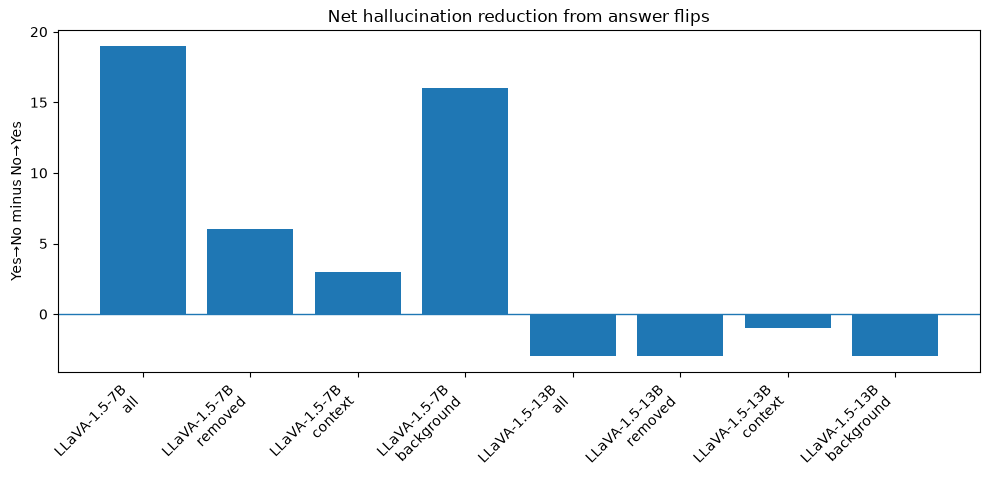

WindowsPath('c:/Users/payal/region-vlm-uncertainty/outputs/plots/final/comparison_answer_flips_net.png')

In [8]:
flip_plot = flips_df.copy()
flip_plot["yes_to_no"] = flip_plot["yes_to_no"].astype(int)
flip_plot["no_to_yes"] = flip_plot["no_to_yes"].astype(int)
flip_plot["net_hallucination_reduction"] = flip_plot["net_hallucination_reduction"].astype(int)

fig, ax = plt.subplots(figsize=(10, 5))

labels = []
values = []

for model in ["LLaVA-1.5-7B", "LLaVA-1.5-13B"]:
    sub = flip_plot[flip_plot["model"] == model].set_index("condition").loc[
        ["all", "removed", "context", "background"]
    ]
    for condition, row in sub.iterrows():
        labels.append(f"{model}\n{condition}")
        values.append(row["net_hallucination_reduction"])

ax.bar(labels, values)
ax.axhline(0, linewidth=1)
ax.set_title("Net hallucination reduction from answer flips")
ax.set_ylabel("Yes→No minus No→Yes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

out = PLOTS / "comparison_answer_flips_net.png"
plt.savefig(out, dpi=200)
plt.show()

out

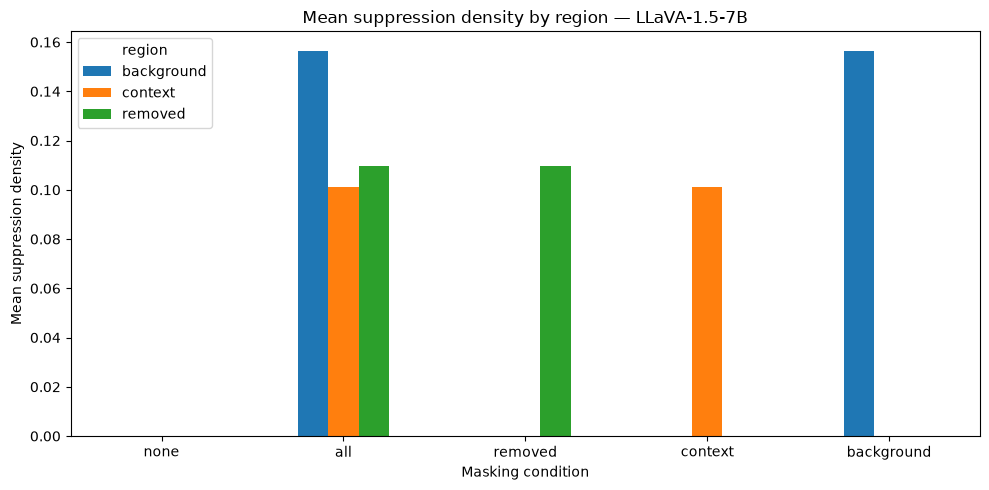

c:\Users\payal\region-vlm-uncertainty\outputs\plots\final\suppression_density_LLaVA157B.png


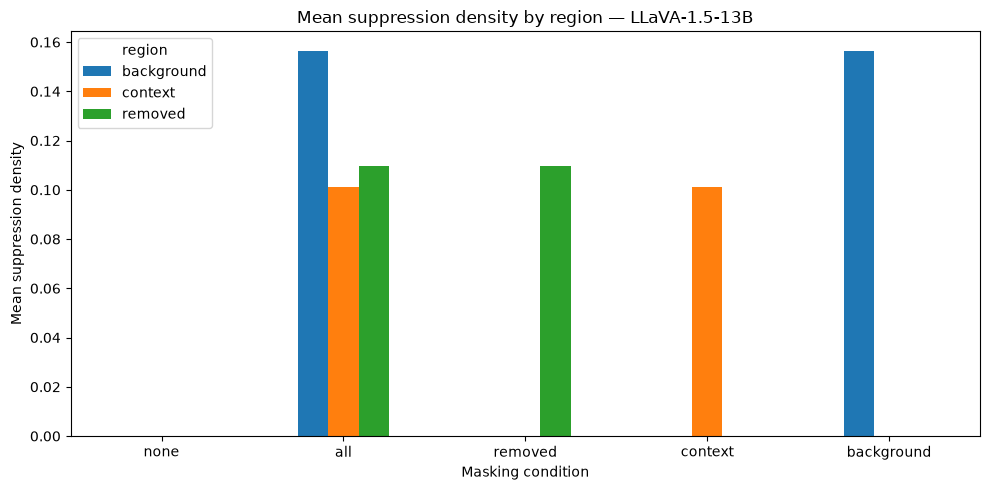

c:\Users\payal\region-vlm-uncertainty\outputs\plots\final\suppression_density_LLaVA1513B.png


In [9]:
density_df = region_df.copy()

density_df = density_df[
    density_df["condition"].isin(["none", "all", "removed", "context", "background"])
]

for model in ["LLaVA-1.5-7B", "LLaVA-1.5-13B"]:
    sub = density_df[density_df["model"] == model]

    pivot = sub.pivot(
        index="condition",
        columns="region",
        values="mean_suppression_density",
    )

    pivot = pivot.loc[["none", "all", "removed", "context", "background"]]

    ax = pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_title(f"Mean suppression density by region — {model}")
    ax.set_xlabel("Masking condition")
    ax.set_ylabel("Mean suppression density")
    plt.xticks(rotation=0)
    plt.tight_layout()

    out = PLOTS / f"suppression_density_{model.replace('.', '').replace('-', '').replace(' ', '_')}.png"
    plt.savefig(out, dpi=200)
    plt.show()

    print(out)

## Final interpretation

The LLaVA-1.5-7B experiment shows a positive causal effect of uncertain-token masking. Global uncertain-token masking reduced hallucination by 3.64 percentage points, and background masking reduced hallucination by 3.07 percentage points. Bootstrap confidence intervals excluded zero for both conditions, indicating a reliable reduction.

The LLaVA-1.5-13B experiment did not reproduce this effect. The baseline hallucination rate was higher, and all masking conditions produced small, negative, non-significant effects. Answer-flip analysis shows that 13B does change some answers, but helpful yes→no corrections are offset by harmful no→yes flips.

Overall, the region-wise epistemic masking effect is model-dependent. It is clearly visible in LLaVA-1.5-7B, especially for global and background masking, but it is not scale-invariant across LLaVA-1.5 model sizes.

# Additional Controls and Sanity Checks

This section adds the final control experiments:

1. multi-seed matched random-token controls,
2. matched low-uncertainty controls,
3. original-image sanity checking.

Together, these controls separate uncertainty ranking, masking location, general information removal, and false-negative cost.


In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "outputs" / "metrics").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_7B = PROJECT_ROOT / "outputs" / "metrics" / "llava7b"
FINAL_PLOTS = PROJECT_ROOT / "outputs" / "plots" / "final"
FINAL_PLOTS.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Metrics folder:", METRICS_7B)


Project root: c:\Users\payal\region-vlm-uncertainty
Metrics folder: c:\Users\payal\region-vlm-uncertainty\outputs\metrics\llava7b


## Matched random-token controls

Each matched random control masks exactly the same number of tokens as the corresponding high-uncertainty condition. Region-specific controls sample only from the same semantic region. Five deterministic random seeds are used.


In [11]:
random_multiseed = pd.read_csv(
    METRICS_7B / "random_control_multiseed_summary.csv"
)

random_pooled_path = (
    METRICS_7B / "random_control_multiseed_pooled_bootstrap.csv"
)

display(random_multiseed)

if random_pooled_path.exists():
    random_pooled = pd.read_csv(random_pooled_path)
    display(random_pooled)
else:
    print("Pooled bootstrap file not found yet:", random_pooled_path)


,condition,num_random_seeds,uncertainty_hallucination_rate_percent,random_hallucination_rate_mean_percent,random_hallucination_rate_std_percent,uncertainty_advantage_mean_pp,uncertainty_advantage_std_pp,minimum_random_rate_percent,maximum_random_rate_percent,seeds_where_uncertainty_better,seeds_where_random_better,seeds_tied
0,all,5,75.862069,75.747126,0.904653,-0.114943,0.904653,74.521073,76.628352,3,2,0
1,background,5,76.436782,76.896552,0.499556,0.459770,0.499556,76.245211,77.586207,4,1,0
2,context,5,78.927203,79.386973,0.373440,0.459770,0.373440,79.118774,79.885057,5,0,0
3,removed,5,78.352490,78.582375,0.548576,0.229885,0.548576,77.777778,79.310345,4,1,0


,condition,num_random_seeds,n_samples,uncertainty_rate_percent,random_mean_rate_percent,uncertainty_advantage_pp,ci_lower_pp,ci_upper_pp,p_value
0,all,5,522,75.862069,75.747126,-0.114943,-1.647510,1.494253,0.8894
1,removed,5,522,78.352490,78.582375,0.229885,-0.306513,0.804598,0.3744
2,context,5,522,78.927203,79.386973,0.459770,-0.421456,1.379310,0.3290
3,background,5,522,76.436782,76.896552,0.459770,-1.034483,2.030651,0.5460


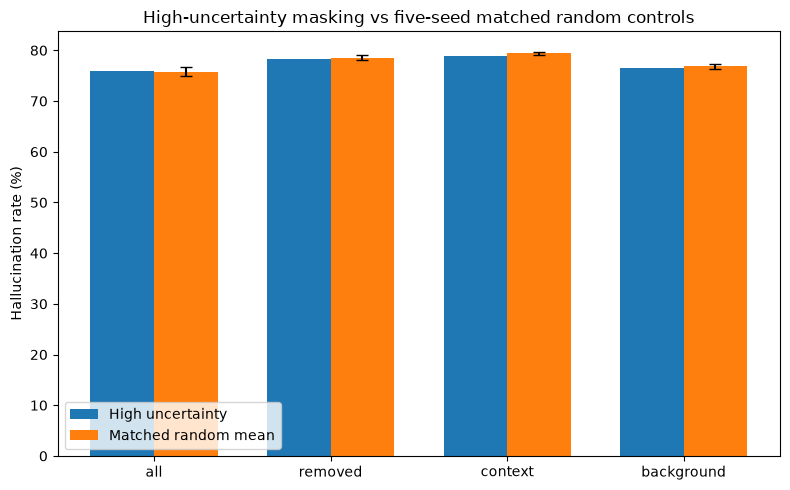

Saved: c:\Users\payal\region-vlm-uncertainty\outputs\plots\final\random_control_multiseed_comparison.png


In [12]:
plot_df = random_multiseed.copy()
order = ["all", "removed", "context", "background"]
plot_df["condition"] = pd.Categorical(
    plot_df["condition"], categories=order, ordered=True
)
plot_df = plot_df.sort_values("condition")

x = list(range(len(plot_df)))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    [i - width / 2 for i in x],
    plot_df["uncertainty_hallucination_rate_percent"],
    width=width,
    label="High uncertainty",
)
ax.bar(
    [i + width / 2 for i in x],
    plot_df["random_hallucination_rate_mean_percent"],
    width=width,
    yerr=plot_df["random_hallucination_rate_std_percent"],
    capsize=4,
    label="Matched random mean",
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["condition"])
ax.set_ylabel("Hallucination rate (%)")
ax.set_title("High-uncertainty masking vs five-seed matched random controls")
ax.legend()
fig.tight_layout()

path = FINAL_PLOTS / "random_control_multiseed_comparison.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Interpretation.** Uncertainty-guided selection does not show a large or consistent advantage over matched random masking. Masking count and masking location explain much of the observed reduction.


## Matched low-uncertainty controls

The low-uncertainty control suppresses the same number of tokens as the corresponding high-uncertainty condition, but selects the lowest-scoring eligible tokens from the same region.


In [13]:
low_summary = pd.read_csv(
    METRICS_7B / "low_uncertainty_control_summary.csv"
)
low_bootstrap = pd.read_csv(
    METRICS_7B / "low_uncertainty_control_paired_bootstrap.csv"
)

display(low_summary)
display(low_bootstrap)


,region,strategy,n,hallucinated_yes,correct_rejection_no,unknown,hallucination_rate,hallucination_rate_percent
0,all,high_uncertainty,522,396,126,0,0.758621,75.862069
1,all,matched_random_seed42,522,392,130,0,0.750958,75.095785
2,all,matched_low_uncertainty,522,415,107,0,0.795019,79.501916
3,removed,high_uncertainty,522,409,113,0,0.783525,78.352490
4,removed,matched_random_seed42,522,411,111,0,0.787356,78.735632
5,removed,matched_low_uncertainty,522,415,107,0,0.795019,79.501916
6,context,high_uncertainty,522,412,110,0,0.789272,78.927203
7,context,matched_random_seed42,522,413,109,0,0.791188,79.118774
8,context,matched_low_uncertainty,522,415,107,0,0.795019,79.501916
9,background,high_uncertainty,522,399,123,0,0.764368,76.436782


,region,comparison,n,high_rate_percent,comparison_rate_percent,high_uncertainty_advantage,high_uncertainty_advantage_pp,ci_lower_pp,ci_upper_pp,p_value
0,all,low,522,75.862069,79.501916,0.036398,3.639847,1.532567,5.938697,0.0014
1,all,random,522,75.862069,75.095785,-0.007663,-0.766284,-2.490421,0.957854,0.4298
2,removed,low,522,78.352490,79.501916,0.011494,1.149425,0.000000,2.298851,0.0678
3,removed,random,522,78.352490,78.735632,0.003831,0.383142,-0.383142,1.149425,0.4594
4,context,low,522,78.927203,79.501916,0.005747,0.574713,-0.574713,1.724138,0.3956
5,context,random,522,78.927203,79.118774,0.001916,0.191571,-0.957854,1.340996,0.8646
6,background,low,522,76.436782,79.501916,0.030651,3.065134,0.957854,5.172414,0.0040
7,background,random,522,76.436782,76.628352,0.001916,0.191571,-1.532567,1.915709,0.9298


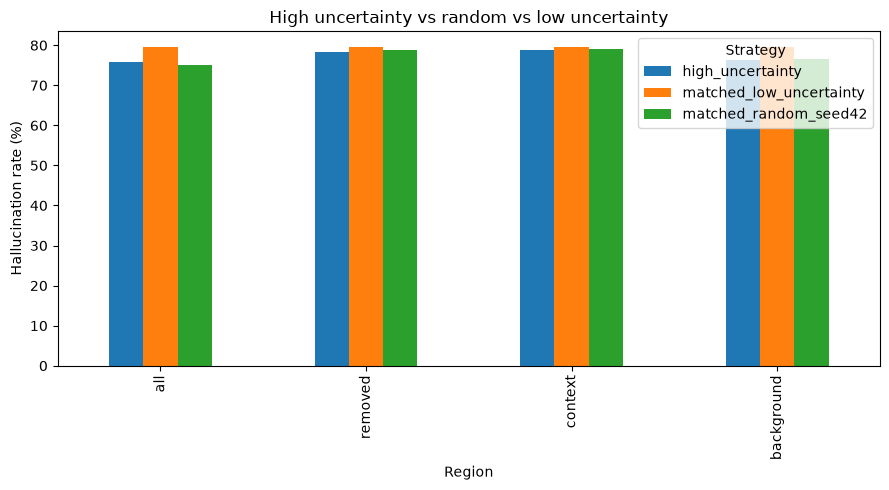

Saved: c:\Users\payal\region-vlm-uncertainty\outputs\plots\final\low_uncertainty_control_comparison.png


In [14]:
low_plot = low_summary.pivot(
    index="region",
    columns="strategy",
    values="hallucination_rate_percent",
).reindex(["all", "removed", "context", "background"])

fig, ax = plt.subplots(figsize=(9, 5))
low_plot.plot(kind="bar", ax=ax)
ax.set_ylabel("Hallucination rate (%)")
ax.set_xlabel("Region")
ax.set_title("High uncertainty vs random vs low uncertainty")
ax.legend(title="Strategy")
fig.tight_layout()

path = FINAL_PLOTS / "low_uncertainty_control_comparison.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Interpretation.** All low-uncertainty conditions matched the no-masking baseline and produced zero answer changes across 522 samples. High-uncertainty global and background suppression therefore changes model decisions more than matched low-uncertainty suppression.


## Original-image sanity check

The original-image experiment uses the same object questions before removal, so the correct answer is **Yes**. This checks whether masking reduces hallucination selectively or also removes valid visual evidence.


In [15]:
original_summary = pd.read_csv(
    METRICS_7B / "original_sanity_summary.csv"
)
original_bootstrap = pd.read_csv(
    METRICS_7B / "original_sanity_paired_bootstrap.csv"
)
original_flips = pd.read_csv(
    METRICS_7B / "original_sanity_answer_flips.csv"
)

display(original_summary)
display(original_bootstrap)
display(original_flips)


,condition,n,correct_yes,false_negative_no,unknown,accuracy,accuracy_percent,false_negative_rate,false_negative_rate_percent
0,none,522,494,28,0,0.946360,94.636015,0.053640,5.363985
1,all,522,482,40,0,0.923372,92.337165,0.076628,7.662835
2,removed,522,492,30,0,0.942529,94.252874,0.057471,5.747126
3,context,522,492,30,0,0.942529,94.252874,0.057471,5.747126
4,background,522,484,38,0,0.927203,92.720307,0.072797,7.279693


,condition,n,baseline_accuracy_percent,masked_accuracy_percent,accuracy_drop,accuracy_drop_pp,ci_lower_pp,ci_upper_pp,p_value
0,all,522,94.636015,92.337165,0.022989,2.298851,0.766284,4.022989,0.0052
1,removed,522,94.636015,94.252874,0.003831,0.383142,-0.383142,1.149425,0.4550
2,context,522,94.636015,94.252874,0.003831,0.383142,0.000000,0.957854,0.2760
3,background,522,94.636015,92.720307,0.019157,1.915709,0.383142,3.448276,0.0136


,condition,n,yes_to_no,no_to_yes,unchanged_yes,unchanged_no,unknown_changes,net_accuracy_change
0,all,522,15,3,479,25,0,-12
1,removed,522,3,1,491,27,0,-2
2,context,522,2,0,492,28,0,-2
3,background,522,13,3,481,25,0,-10


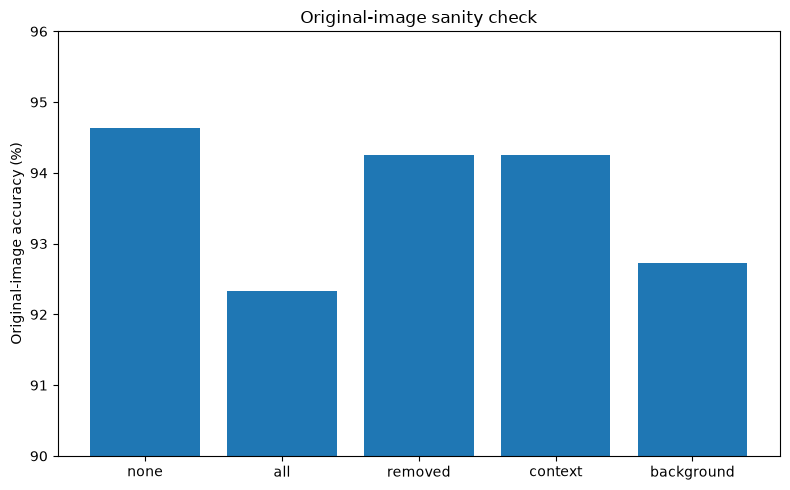

Saved: c:\Users\payal\region-vlm-uncertainty\outputs\plots\final\original_image_sanity_accuracy.png


In [16]:
original_plot = original_summary.copy()
order = ["none", "all", "removed", "context", "background"]
original_plot["condition"] = pd.Categorical(
    original_plot["condition"], categories=order, ordered=True
)
original_plot = original_plot.sort_values("condition")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    original_plot["condition"],
    original_plot["accuracy_percent"],
)
ax.set_ylabel("Original-image accuracy (%)")
ax.set_title("Original-image sanity check")
ax.set_ylim(90, 96)
fig.tight_layout()

path = FINAL_PLOTS / "original_image_sanity_accuracy.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Interpretation.** Global and background masking significantly reduce correct recognition on original images. The hallucination reduction on removed images therefore has a false-negative cost and is not a purely selective correction.


## Updated synthesis

The additional controls refine the causal interpretation:

- High-uncertainty global and background masking reduces hallucination relative to no masking.
- High-uncertainty masking clearly differs from matched low-uncertainty masking.
- High-uncertainty masking does not consistently outperform matched random masking.
- Global and background masking also reduce correct recognition on original images.
- LLaVA-1.5-13B does not reproduce the 7B effect.

The most defensible conclusion is that high-uncertainty global and background tokens identify visually influential parts of the representation, but the intervention is neither uniquely uncertainty-specific nor cost-free.
